# Pass-Rusher Gravity GNN — Pipeline Notebook (GNN-V1)

End-to-end run for the pass-rusher gravity Graph Neural Network. The plan is described in detail in the branch README (`Data Cleaning + Engineering/gnn/README.md`). This notebook is the canonical entrypoint; all heavy lifting lives in importable Python modules under `gnn/`.

Pipeline stages:
1. Load `play_context.csv`, `play_attention_scores.csv`, and player metadata.
2. Filter to gravity-eligible pass-rush plays.
3. Stream `gravity_base.csv` and build per-frame PyTorch-Geometric graphs across the pass-rush window.
4. Run two tabular baselines (Ridge, HistGradientBoosting) on the same labels for comparison.
5. Train GraphSAGE and GATv2 expected-attention models with grouped (gameId) train/val/test split.
6. Aggregate frame predictions to play-rusher level, write `gnn_attention_scores.csv` and `gnn_player_gravity.csv`.
7. Validate (per-position metrics, split-half stability, top players).

In [1]:
import sys; print(sys.executable)

import os 
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'

/opt/anaconda3/bin/python


## 0. Environment setup
If you haven't already, install dependencies via `pip install -r requirements.txt` or `conda env create -f environment.yml`. PyTorch Geometric requires PyTorch be installed first; see the README for platform-specific install commands.

In [2]:
import sys
from pathlib import Path

# Make `gnn` importable regardless of where the notebook is launched from.
NOTEBOOK_DIR = Path.cwd()
DCE_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'gnn').exists() else NOTEBOOK_DIR.parent
if str(DCE_DIR) not in sys.path:
    sys.path.insert(0, str(DCE_DIR))
print('importing gnn from', DCE_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from gnn import config
from gnn.config import TrainConfig, pick_device
from gnn.dataset import build_frame_graphs, save_frame_graphs, load_frame_graphs, to_pyg_dataset, cache_path
from gnn.data_filters import filter_eligible_plays
from gnn.splits import grouped_split
from gnn.models import build_model
from gnn.train import train_model
from gnn.evaluate import predict_play_rusher, regression_metrics, metrics_by_position_group, split_half_stability
from gnn.infer import write_play_rusher_predictions, write_player_gravity
from gnn.lookups import rusher_position_group_lookup
from gnn.baselines import build_baseline_table, fit_linear_baseline, fit_tree_baseline

# Knobs you'll usually touch: max_plays caps the eligible play count for fast iteration; set to None for full run.
MAX_PLAYS = None  # full eligible set (~7.4K plays). For fast iteration set to 400 or 1000;
                 # min_plays=25 in module 8 expects roughly the full dataset to produce
                 # a non-empty qualified-player rollup.
FRAMES_PER_PLAY = config.FRAMES_PER_PLAY
# Auto-detect: cuda > mps (Apple Silicon) > cpu. Override with 'cuda', 'mps', or 'cpu' if you want to force one.
DEVICE = pick_device('auto')
RANDOM_SEED = 42
print('config:', dict(max_plays=MAX_PLAYS, frames_per_play=FRAMES_PER_PLAY, device=DEVICE))
print('torch:', torch.__version__, '| cuda available:', torch.cuda.is_available(),
      '| mps available:', getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available())

importing gnn from /Users/moulikchatterjee/Documents/UCLA /Clubs and Activities/Bruin Sports Analytics/Research/Football Research 2026/Football Gravity Metrics/BSA-Football-2026-Gravity-Metrics
config: {'max_plays': None, 'frames_per_play': 6, 'device': 'mps'}
torch: 2.11.0 | cuda available: False | mps available: True


## 1. Load play context and labels

In [3]:
play_context = pd.read_csv(config.PLAY_CONTEXT_CSV)
play_attention = pd.read_csv(config.PLAY_ATTENTION_CSV)
for c in ['gameId', 'playId']:
    play_context[c] = play_context[c].astype(int)
    play_attention[c] = play_attention[c].astype(int)
play_attention['rusher_nflId'] = play_attention['rusher_nflId'].astype(int)

print('plays in context:', len(play_context))
print('rusher rows in attention:', len(play_attention))
play_attention.head()

plays in context: 8557
rusher rows in attention: 30971


,gameId,playId,rusher_nflId,avg_attention_score,rusher_name
0,2021090900,97,41263,0.461538,Demarcus Lawrence
1,2021090900,97,42403,0.615385,Randy Gregory
2,2021090900,97,44955,1.307692,Carlos Watkins
3,2021090900,97,53441,1.000000,Micah Parsons
4,2021090900,97,53504,0.615385,Osa Odighizuwa


In [4]:
eligible = filter_eligible_plays(play_context)
print(f'eligible plays after filter: {len(eligible):,}  (of {len(play_context):,})')
eligible[['offenseFormation','passCoverage','passCoverageType','dropBackType','playAction']].describe(include='all').T

eligible plays after filter: 7,441  (of 8,557)


,count,unique,top,freq
offenseFormation,7441,7,SHOTGUN,4988
passCoverage,7441,12,Cover 3,2288
passCoverageType,7441,3,Zone,4917
dropBackType,7441,2,Traditional,6542
playAction,7441,2,False,6045


## 2. Build frame-level graphs

Cached to `Data Cleaning + Engineering/gnn/cache/`. Re-run with `force=True` if the schema or filters change.

In [5]:
cache_file = cache_path(f'frame_graphs_max{MAX_PLAYS}_fp{FRAMES_PER_PLAY}.pkl')
force_rebuild = False
if cache_file.exists() and not force_rebuild:
    print('loading cached graphs from', cache_file)
    graphs = load_frame_graphs(cache_file)
else:
    graphs = build_frame_graphs(
        play_context=play_context,
        play_attention=play_attention,
        frames_per_play=FRAMES_PER_PLAY,
        max_plays=MAX_PLAYS,
        chunksize=300_000,
        verbose=True,
    )
    save_frame_graphs(graphs, cache_file)
print(f'built {len(graphs)} frame graphs')

  ... 0 plays processed, 0 graphs
  ... 282 plays processed, 1692 graphs
  ... 553 plays processed, 3318 graphs
  ... 835 plays processed, 5010 graphs
  ... 1121 plays processed, 6726 graphs
  ... 1390 plays processed, 8340 graphs
  ... 1687 plays processed, 10122 graphs
  ... 1959 plays processed, 11754 graphs
  ... 2218 plays processed, 13308 graphs
  ... 2494 plays processed, 14964 graphs
  ... 2789 plays processed, 16728 graphs
  ... 3048 plays processed, 18282 graphs
  ... 3313 plays processed, 19872 graphs
  ... 3583 plays processed, 21492 graphs
  ... 3889 plays processed, 23328 graphs
  ... 4158 plays processed, 24942 graphs
  ... 4441 plays processed, 26640 graphs
  ... 4699 plays processed, 28188 graphs
  ... 4966 plays processed, 29790 graphs
  ... 5238 plays processed, 31422 graphs
  ... 5512 plays processed, 33066 graphs
  ... 5798 plays processed, 34782 graphs
  ... 6063 plays processed, 36372 graphs
  ... 6341 plays processed, 38040 graphs
  ... 6610 plays processed, 396

In [6]:
# Quick sanity look at the first graph
g0 = graphs[0]
print('nodes:', g0.x.shape, '\nedge_index:', g0.edge_index.shape, '\nedge_attr:', g0.edge_attr.shape)
print('rushers in frame:', int(g0.rusher_mask.sum()))
print('targets:', g0.y[g0.rusher_mask])
print('global feature dim:', g0.u.shape)

nodes: (22, 40) 
edge_index: (2, 462) 
edge_attr: (462, 9)
rushers in frame: 4
targets: [1.0833334 0.5833333 1.        1.       ]
global feature dim: (42,)


## 3. Convert to PyTorch-Geometric and split by gameId
Holding out by `gameId` so train/val/test never share frames or plays.

In [7]:
data_list = to_pyg_dataset(graphs)
game_ids = [int(g.game_id) for g in graphs]
split = grouped_split(game_ids, val_fraction=0.15, test_fraction=0.15, seed=RANDOM_SEED)
train_data = [data_list[i] for i in split.train_idx]
val_data = [data_list[i] for i in split.val_idx]
test_data = [data_list[i] for i in split.test_idx]
print('train graphs', len(train_data), 'val', len(val_data), 'test', len(test_data))
print('train games', len(split.train_games), 'val', len(split.val_games), 'test', len(split.test_games))

train graphs 30419 val 6702 test 6732
train games 86 val 18 test 18


## 4. Tabular baselines

We compare the GNN against ridge regression and a HistGradientBoosting tree on the same labels (`avg_attention_score`) and play-level globals. The GNN must beat or match these on held-out MAE/RMSE for the graph structure to be earning its keep.

In [8]:
rusher_pos_lookup = rusher_position_group_lookup()
tabular = build_baseline_table(play_attention, play_context, rusher_pos_lookup)
tabular_train = tabular[tabular['gameId'].isin(split.train_games)].reset_index(drop=True)
tabular_val = tabular[tabular['gameId'].isin(split.val_games)].reset_index(drop=True)
tabular_test = tabular[tabular['gameId'].isin(split.test_games)].reset_index(drop=True)
print('tabular sizes train/val/test:', len(tabular_train), len(tabular_val), len(tabular_test))

tabular sizes train/val/test: 21467 4785 4719


In [9]:
ridge_model, _, ridge_val_pred = fit_linear_baseline(tabular_train, tabular_val)
tree_model, _, tree_val_pred = fit_tree_baseline(tabular_train, tabular_val)

ridge_metrics = regression_metrics(tabular_val['avg_attention_score'].to_numpy(), ridge_val_pred)
tree_metrics = regression_metrics(tabular_val['avg_attention_score'].to_numpy(), tree_val_pred)
pd.DataFrame({'ridge': ridge_metrics, 'tree': tree_metrics}).T

,mae,rmse,r2,spearman,pearson,n
ridge,0.336759,0.430141,0.251557,0.479533,0.501877,4785.0
tree,0.335981,0.429702,0.253084,0.479869,0.503389,4785.0


## 5. Train GraphSAGE

In [10]:
cfg = TrainConfig(epochs=20, batch_size=128, lr=1e-3, hidden_dim=64, num_layers=3, dropout=0.2,
                  device=DEVICE, seed=RANDOM_SEED, early_stopping_patience=5)
sage_model = build_model('graphsage', hidden_dim=cfg.hidden_dim, num_layers=cfg.num_layers, dropout=cfg.dropout)
sage_history = train_model(sage_model, train_data, val_data, cfg=cfg, checkpoint_name='graphsage_best.pt')
print('GraphSAGE best val MSE:', sage_history.best_val_loss)

[train] using device: mps
epoch 000 | train 0.2605 | val 0.1629 *
epoch 001 | train 0.1737 | val 0.1537 *
epoch 002 | train 0.1674 | val 0.1522 *
epoch 003 | train 0.1630 | val 0.1493 *
epoch 004 | train 0.1597 | val 0.1449 *
epoch 005 | train 0.1546 | val 0.1413 *
epoch 006 | train 0.1501 | val 0.1364 *
epoch 007 | train 0.1464 | val 0.1349 *
epoch 008 | train 0.1434 | val 0.1316 *
epoch 009 | train 0.1402 | val 0.1331
epoch 010 | train 0.1380 | val 0.1293 *
epoch 011 | train 0.1353 | val 0.1339
epoch 012 | train 0.1333 | val 0.1278 *
epoch 013 | train 0.1314 | val 0.1251 *
epoch 014 | train 0.1299 | val 0.1260
epoch 015 | train 0.1271 | val 0.1248 *
epoch 016 | train 0.1262 | val 0.1284
epoch 017 | train 0.1242 | val 0.1237 *
epoch 018 | train 0.1232 | val 0.1219 *
epoch 019 | train 0.1220 | val 0.1217 *
GraphSAGE best val MSE: 0.12173776656291407


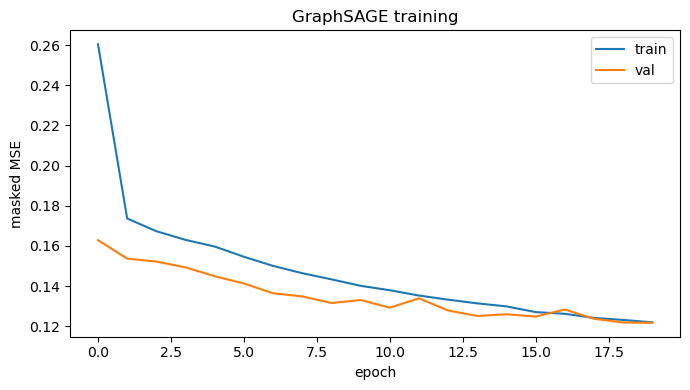

In [11]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(sage_history.train_losses, label='train')
ax.plot(sage_history.val_losses, label='val')
ax.set_xlabel('epoch'); ax.set_ylabel('masked MSE'); ax.set_title('GraphSAGE training'); ax.legend(); plt.tight_layout()

## 6. Train GATv2

In [13]:
gat_model = build_model('gatv2', hidden_dim=cfg.hidden_dim, num_layers=cfg.num_layers, dropout=cfg.dropout, heads=4, use_edge_features=True)
gat_history = train_model(gat_model, train_data, val_data, cfg=cfg, checkpoint_name='gatv2_best.pt')
print('GATv2 best val MSE:', gat_history.best_val_loss)

[train] using device: mps
epoch 000 | train 0.2899 | val 0.2380 *
epoch 001 | train 0.2413 | val 0.1918 *
epoch 002 | train 0.1949 | val 0.1361 *
epoch 003 | train 0.1562 | val 0.1135 *
epoch 004 | train 0.1386 | val 0.1059 *
epoch 005 | train 0.1289 | val 0.0989 *
epoch 006 | train 0.1240 | val 0.0982 *
epoch 007 | train 0.1193 | val 0.0939 *
epoch 008 | train 0.1153 | val 0.0905 *
epoch 009 | train 0.1123 | val 0.0904 *
epoch 010 | train 0.1094 | val 0.0876 *
epoch 011 | train 0.1059 | val 0.0879
epoch 012 | train 0.1036 | val 0.0856 *
epoch 013 | train 0.1020 | val 0.0845 *
epoch 014 | train 0.0998 | val 0.0858
epoch 015 | train 0.0978 | val 0.0833 *
epoch 016 | train 0.0962 | val 0.0859
epoch 017 | train 0.0946 | val 0.0842
epoch 018 | train 0.0933 | val 0.0831 *
epoch 019 | train 0.0922 | val 0.0815 *
GATv2 best val MSE: 0.08146919417260334


## 7. Evaluate on the held-out test split

In [14]:
sage_pred_df = predict_play_rusher(sage_model, test_data, device=DEVICE)
gat_pred_df = predict_play_rusher(gat_model, test_data, device=DEVICE)

sage_metrics = regression_metrics(sage_pred_df['actual_attention_gnn'].to_numpy(), sage_pred_df['expected_attention_gnn'].to_numpy())
gat_metrics = regression_metrics(gat_pred_df['actual_attention_gnn'].to_numpy(), gat_pred_df['expected_attention_gnn'].to_numpy())

summary = pd.DataFrame({
    'ridge_val': ridge_metrics,
    'tree_val': tree_metrics,
    'graphsage_test': sage_metrics,
    'gatv2_test': gat_metrics,
}).T
summary

,mae,rmse,r2,spearman,pearson,n
ridge_val,0.336759,0.430141,0.251557,0.479533,0.501877,4785.0
tree_val,0.335981,0.429702,0.253084,0.479869,0.503389,4785.0
graphsage_test,0.249605,0.326667,0.540544,0.748909,0.737872,4719.0
gatv2_test,0.177662,0.240188,0.751609,0.874956,0.879215,4719.0


In [15]:
metrics_by_position_group(gat_pred_df, rusher_pos_lookup)

,mae,rmse,r2,spearman,pearson,n
position_group,,,,,,
DB,0.191185,0.243953,0.574187,0.809918,0.814427,147
DI,0.181892,0.243225,0.652530,0.841999,0.836772,1777
Edge,0.172396,0.236253,0.701717,0.826563,0.855440,2629
LB,0.203802,0.264669,0.694022,0.886062,0.879740,166


## 8. Choose the better model and write outputs

Pick the model with the lower test MAE. Write `gnn_attention_scores.csv` (play-rusher) and `gnn_player_gravity.csv` (player rollup, z-scored).

In [22]:
best_name, best_pred_df = ('gatv2', gat_pred_df) if gat_metrics['mae'] <= sage_metrics['mae'] else ('graphsage', sage_pred_df)
print('selected', best_name)

# Run inference on ALL graphs so the output covers every eligible play, not just the test split.
best_model = gat_model if best_name == 'gatv2' else sage_model
all_pred_df = predict_play_rusher(best_model, data_list, device=DEVICE)

play_rusher = write_play_rusher_predictions(all_pred_df, play_attention)
# min_plays=25 follows the convention from the existing player_attention_scores rollup.
# Requires roughly the full dataset (MAX_PLAYS=None) to produce non-empty output, since
# rushers average ~45 plays across the 7.4K eligible plays.
player_df = write_player_gravity(play_rusher, rusher_position_lookup=rusher_pos_lookup, min_plays=75)
print('wrote', len(play_rusher), 'play-rusher rows to', config.GNN_ATTENTION_CSV)
print('wrote', len(player_df), 'qualified players to', config.GNN_PLAYER_GRAVITY_CSV)
player_df.index = range(1, len(player_df) + 1)
player_df.head(15)

selected gatv2
[write_player_gravity] 685 unique rushers, plays/rusher: median=18 max=228 min=1 | min_plays=75 -> 166 qualified
wrote 30954 play-rusher rows to /Users/moulikchatterjee/Documents/UCLA /Clubs and Activities/Bruin Sports Analytics/Research/Football Research 2026/Football Gravity Metrics/BSA-Football-2026-Gravity-Metrics/Data Cleaning + Engineering/outputs_csv/gnn_attention_scores.csv
wrote 166 qualified players to /Users/moulikchatterjee/Documents/UCLA /Clubs and Activities/Bruin Sports Analytics/Research/Football Research 2026/Football Gravity Metrics/BSA-Football-2026-Gravity-Metrics/Data Cleaning + Engineering/outputs_csv/gnn_player_gravity.csv


,rusher_nflId,rusher_name,plays,mean_actual,mean_expected,mean_gravity,std_gravity,gravity_z,gravity_pct,position_group
1,41239,Aaron Donald,228,1.594122,1.488486,0.105637,0.283736,2.889748,100.000000,DI
2,43441,Matt Ioannidis,122,1.522077,1.433695,0.088382,0.252244,2.358413,99.397590,DI
3,53467,Christian Barmore,165,1.612486,1.528978,0.083508,0.256356,2.208328,98.795181,DI
4,40074,William Gholston,96,1.427544,1.351728,0.075816,0.306046,1.971477,98.192771,Edge
5,43333,Jihad Ward,84,1.335851,1.266304,0.069546,0.225989,1.778407,97.590361,Edge
6,44813,Myles Garrett,170,1.084141,1.016188,0.067953,0.221380,1.729349,96.987952,Edge
7,44938,Samson Ebukam,79,1.174086,1.106204,0.067882,0.275142,1.727144,96.385542,Edge
8,44815,Solomon Thomas,111,1.485059,1.420026,0.065033,0.277902,1.639424,95.783133,DI
9,43296,DeForest Buckner,183,1.472096,1.407478,0.064617,0.239777,1.626629,95.180723,DI
10,46249,Folorunso Fatukasi,102,1.543350,1.480002,0.063348,0.210655,1.587552,94.578313,DI


## 9. Validation
Three quick checks aligned with the literature:
- **Split-half stability** — gravity_gnn correlates across random halves of plays per player.
- **Position group breakdown** — Edge and DI groups should not be systematically negative.
- **Top performers** — pass the eye test against known elite rushers.

In [17]:
stab = split_half_stability(play_rusher, seed=RANDOM_SEED)
print('split-half Spearman of gravity_gnn:', round(stab, 3) if stab == stab else 'nan')

if 'position_group' in player_df.columns:
    print(player_df.groupby('position_group')['mean_gravity'].describe())

split-half Spearman of gravity_gnn: 0.316
                count      mean       std       min       25%       50%  \
position_group                                                            
DB                2.0 -0.031299  0.061138 -0.074530 -0.052914 -0.031299   
DI              115.0  0.015530  0.040306 -0.101166 -0.004295  0.012703   
Edge            171.0  0.008237  0.036632 -0.090667 -0.018361  0.005302   
LB               18.0 -0.039093  0.050348 -0.127670 -0.071264 -0.031222   

                     75%       max  
position_group                      
DB             -0.009683  0.011933  
DI              0.040063  0.114798  
Edge            0.035455  0.133888  
LB             -0.013794  0.067825  


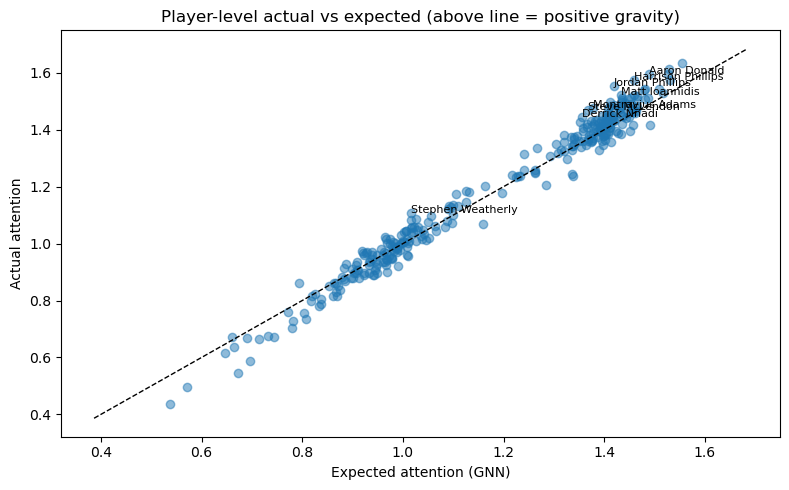

In [19]:
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(player_df['mean_expected'], player_df['mean_actual'], alpha=0.5)
lim = (min(player_df['mean_expected'].min(), player_df['mean_actual'].min()) - 0.05,
       max(player_df['mean_expected'].max(), player_df['mean_actual'].max()) + 0.05)
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlabel('Expected attention (GNN)')
ax.set_ylabel('Actual attention')
ax.set_title('Player-level actual vs expected (above line = positive gravity)')
for _, r in player_df.head(8).iterrows():
    ax.annotate(r['rusher_name'], (r['mean_expected'], r['mean_actual']), fontsize=8)
plt.tight_layout()

In [23]:
print('Top 25 by gravity_gnn:')
player_df[['rusher_name','plays','mean_actual','mean_expected','mean_gravity','gravity_z','gravity_pct']].head(25)

Top 25 by gravity_gnn:


,rusher_name,plays,mean_actual,mean_expected,mean_gravity,gravity_z,gravity_pct
1,Aaron Donald,228,1.594122,1.488486,0.105637,2.889748,100.000000
2,Matt Ioannidis,122,1.522077,1.433695,0.088382,2.358413,99.397590
3,Christian Barmore,165,1.612486,1.528978,0.083508,2.208328,98.795181
4,William Gholston,96,1.427544,1.351728,0.075816,1.971477,98.192771
5,Jihad Ward,84,1.335851,1.266304,0.069546,1.778407,97.590361
6,Myles Garrett,170,1.084141,1.016188,0.067953,1.729349,96.987952
7,Samson Ebukam,79,1.174086,1.106204,0.067882,1.727144,96.385542
8,Solomon Thomas,111,1.485059,1.420026,0.065033,1.639424,95.783133
9,DeForest Buckner,183,1.472096,1.407478,0.064617,1.626629,95.180723
10,Folorunso Fatukasi,102,1.543350,1.480002,0.063348,1.587552,94.578313


## Next steps (v2)
- Add stunt detection so screeners and loopers get separate expected-attention conditioning.
- Switch to a temporal GNN (e.g. EvolveGCN or a small Transformer over frames) once the static frame-graph baseline is stable.
- Add edge-type heterogeneity (blocker→rusher candidate vs same-team) instead of relying on edge feature flags.
- Replace the cap at 3.0 s with the actual TTT from the play if available, to avoid truncating long dropbacks.